# $\textcolor{green}{\text{Mesh Grid Checks}}$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math 

from neo_detect.asteroid import Asteroid

In [5]:
# same asteroid params as before
diameter = 30.0
albedo = 0.14
G = 0.15

asteroid = Asteroid(diameter = diameter, albedo = albedo, G = G)

# xy plane from -2 to 2 AU at 1200 points each, 1200x1200 grid. pretty sure this is what I need
# pull mesh_grid and cartesian_grid from asteroid class and use here
x = np.linspace(-2.0, 2.0, 1200)
y = np.linspace(-2.0, 2.0, 1200)

X, Y = asteroid.mesh_grid(x, y)
r, delta, phase = asteroid.cartesian_grid(X, Y)

print('Grid size confirmation:')
print('X:', X.shape, 'Y:', Y.shape)
print('r:', r.shape, 'delta:', delta.shape, 'phase:', phase.shape)

D = 30.0, H = 25.367073637206094
Grid size confirmation:
X: (1200, 1200) Y: (1200, 1200)
r: (1200, 1200) delta: (1200, 1200) phase: (1200, 1200)


$\textcolor{green}{\text{Looks good!! Now try plotting to look at x axis and see helio and geocentric distances. Then  plot for phase angle}}$

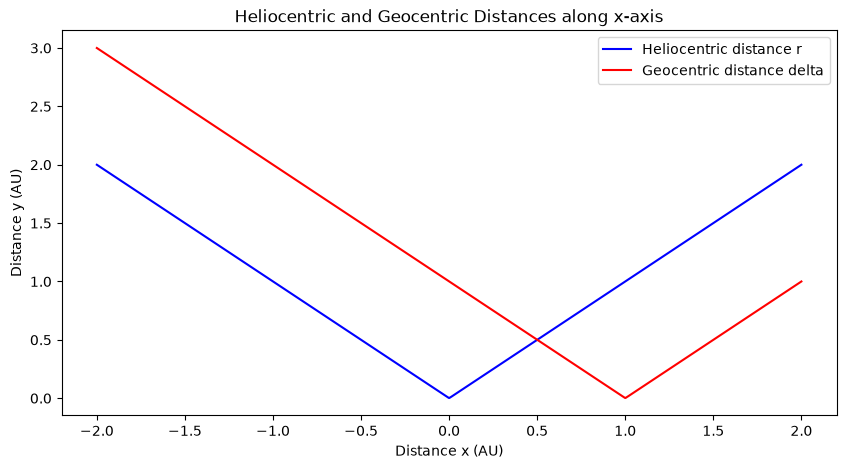

In [61]:
# plot along x axis
half_distance = len(y) // 2

fig = plt.figure(figsize=(10, 5))

# inline suggestions figured this out so hopefully it's correct
plt.plot(x, r[half_distance, :], label='Heliocentric distance r', color = 'blue')
plt.plot(x, delta[half_distance, :], label='Geocentric distance delta', color = 'red')
plt.xlabel('Distance x (AU)')
plt.ylabel('Distance y (AU)')
plt.title('Heliocentric and Geocentric Distances along x-axis')
plt.legend()

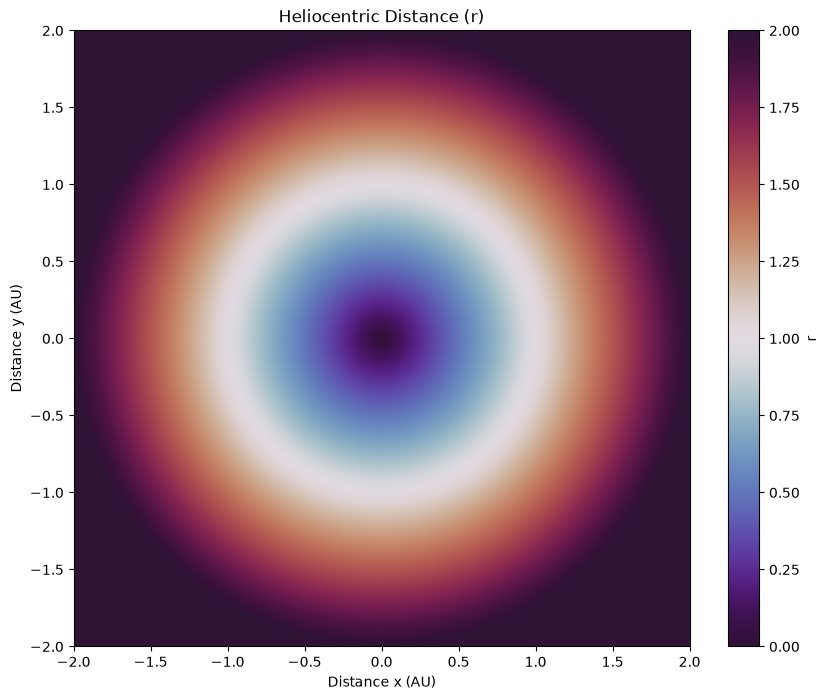

In [55]:
# heliocentric distance colormap with colorbar

fig = plt.figure(figsize=(10, 8))
im = plt.imshow(r, extent=(-2, 2, -2, 2), origin='lower', cmap='twilight_shifted', vmin=0, vmax=2)

plt.xlabel('Distance x (AU)')
plt.ylabel('Distance y (AU)')
plt.title('Heliocentric Distance (r)')
plt.colorbar(label = 'r')

$\textcolor{green}{\text{Looks like an eyeball, pretty cool!! Expected to be centered because it's heliocentric}}$

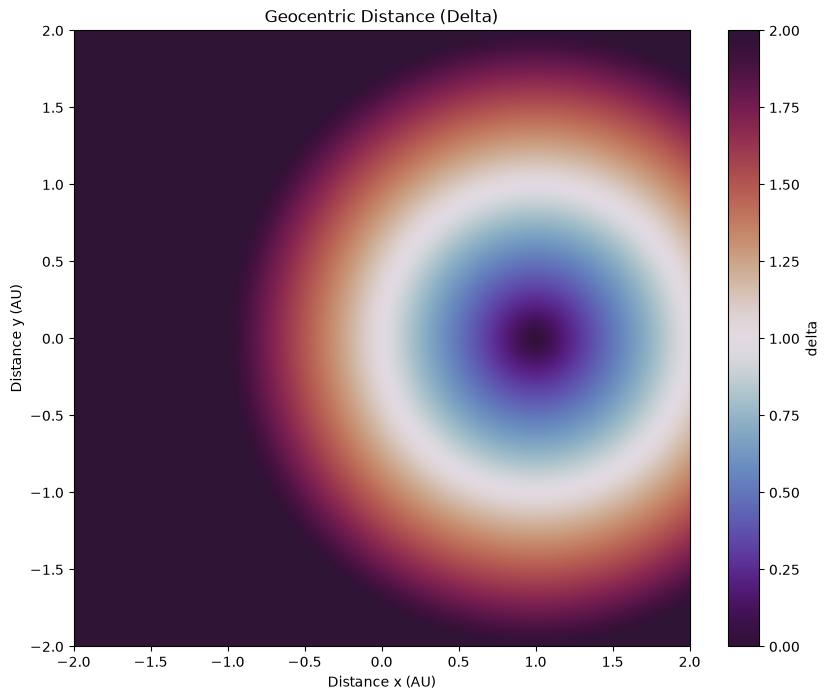

In [54]:
# geocentric distance colormap with colorbar

fig = plt.figure(figsize=(10, 8))
im = plt.imshow(delta, origin='lower', extent=[x.min(), x.max(), y.min(), y.max()], aspect='equal', cmap='twilight_shifted', vmin=0, vmax=2
)
plt.xlabel('Distance x (AU)')
plt.ylabel('Distance y (AU)')
plt.title('Geocentric Distance (Delta)')
plt.colorbar(label='delta')

plt.show()

$\textcolor{green}{\text{Also looks good!! Expected to be centered around x = 1.0 because it's geocentric}}$

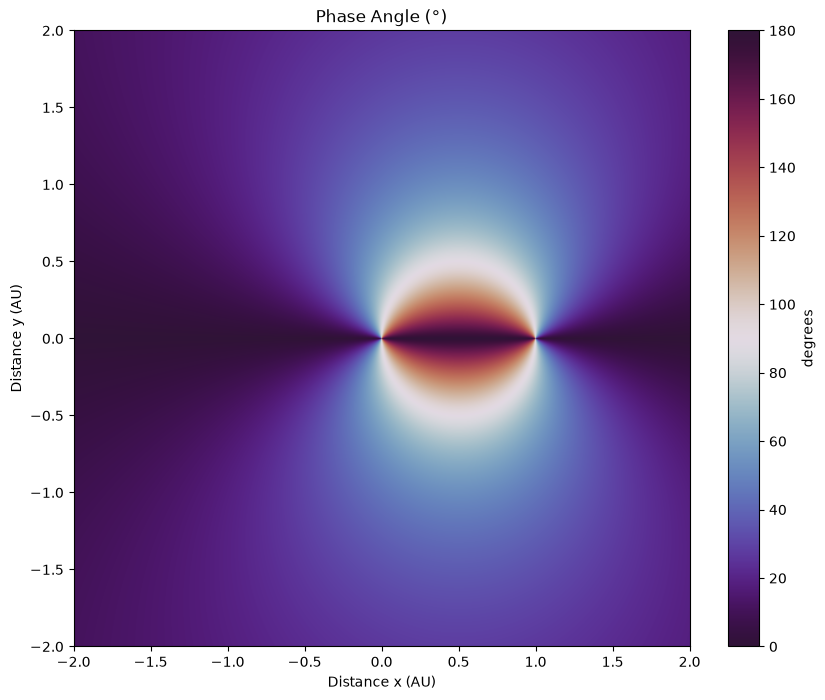

In [59]:
# phase angle plot colormap with colorbar
plt.figure(figsize=(10, 8))
plt.imshow(phase, origin='lower', extent=[x.min(), x.max(), y.min(), y.max()], aspect='equal', cmap='twilight_shifted', vmin=0, vmax=180)

plt.xlabel('Distance x (AU)')
plt.ylabel('Distance y (AU)')
plt.title('Phase Angle (°)')
plt.colorbar(label='degrees')
plt.show()

$\textcolor{green}{\text{Looks funky but should be what's expected from 0 - 180 degrees}}$